# Stage 04: the plan parser

**Wall segments in, a structural grid and candidate column positions out.**

Walls vote for grid lines: a wall running along y votes for a vertical line
at its midpoint x, weighted by its length, and votes closer together than a
merge tolerance collapse into one line. Nodes are the crossings of the
surviving lines; user constraints can block nodes (column-free zones), and
genuinely inclined walls — further than 10° from either axis — are kept out
of the voting and handled separately, offering a candidate wherever a grid
line crosses one.

Three things changed in this rebuild, all in the direction of agreeing with
the stage 02 corpus derivation (which is what makes the derived ground truth
*reachable* — stage 12 reports that rate, and it is now 7/7 on the held-out
plans):

1. **Load-bearing awareness.** When walls carry a thickness (the demo plans
   now do, as a fifth number per wall), only walls at or above the 160 mm
   load-bearing cut vote for grid lines, and every node is tested for
   containment inside a load-bearing wall — the same test, with the same
   tolerance, that derived the corpus ground truth. Plans without thickness
   (the synthetic office) fall back to all-walls voting and a stated nominal
   containment width.
2. **Corpus-aligned voting.** Votes sit at wall midpoints, are weighted by
   the wall's length component along its own axis, and walls shorter than 5%
   of the plan are drawing detail and do not vote (`min_wall_frac`). With
   `merge_tol="auto"` the tolerance is 1.5% of the voting walls' extent —
   the corpus rule — and the parsed grid reproduces the ground truth's grid
   to the millimetre.
3. **Fixed columns.** Columns the drawing itself marks are *input*, not
   answer: they are recorded and stage 05 keeps them in every candidate,
   the same way the ground-truth derivation keeps annotated columns (and
   the same way the closest prior art marks locations "required").

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

walls = json.loads((Path("..") / "data" / "sample_plan.json").read_text())["walls"]
cons = json.loads((Path("..") / "data" / "constraints.json").read_text())
grid = P.parse_plan(walls, cons)
print(f"sample office: {len(grid['x_lines'])} x-lines, "
      f"{len(grid['y_lines'])} y-lines, {len(grid['nodes'])} nodes, "
      f"{int(grid['blocked'].sum())} blocked by the atrium, "
      f"{int(grid['in_wall'].sum())} on the wall fabric")

sample office: 7 x-lines, 5 y-lines, 35 nodes, 1 blocked by the atrium, 34 on the wall fabric


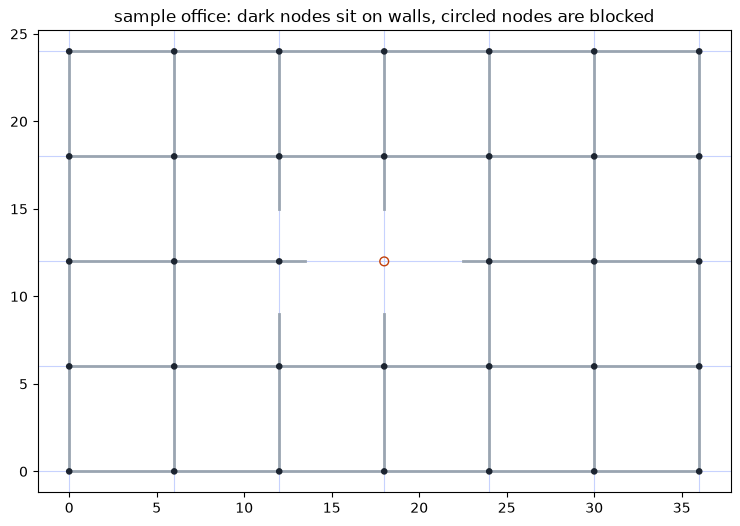

In [2]:
def draw(grid, title, path=None, gt=None):
    fig, ax = plt.subplots(figsize=(9, 6))
    for w in np.asarray(grid["walls"]):
        ax.plot([w[0], w[2]], [w[1], w[3]], color="#9aa5b1", lw=2)
    for w in np.asarray(grid.get("skew_walls", [])).reshape(-1, 4):
        ax.plot([w[0], w[2]], [w[1], w[3]], color="#ea7317", lw=3)
    for x in grid["x_lines"]:
        ax.axvline(x, color="#c7d2fe", lw=0.8, zorder=0)
    for y in grid["y_lines"]:
        ax.axhline(y, color="#c7d2fe", lw=0.8, zorder=0)
    n = np.asarray(grid["nodes"])
    ax.scatter(n[~grid["blocked"], 0], n[~grid["blocked"], 1], s=14,
               c=np.where(grid["in_wall"][~grid["blocked"]],
                          "#1c2430", "#cbd5e1"), zorder=3)
    if grid["blocked"].any():
        ax.scatter(n[grid["blocked"], 0], n[grid["blocked"], 1], s=40,
                   facecolors="none", edgecolors="#c2410c", zorder=3)
    s = np.asarray(grid.get("skew_nodes", [])).reshape(-1, 2)
    if len(s):
        ax.scatter(s[:, 0], s[:, 1], s=46, marker="D", facecolors="none",
                   edgecolors="#ea7317", zorder=4)
    ax.set_aspect("equal"); ax.set_title(title)
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

draw(grid, "sample office: dark nodes sit on walls, circled nodes are blocked",
     Path("..") / "figures" / "04_parsed_plan.png")

demo_01: 107 walls, 53 load-bearing at 160 mm; grid 8 x 7, 42 of 56 nodes inside a load-bearing wall, 1 drawn column(s)


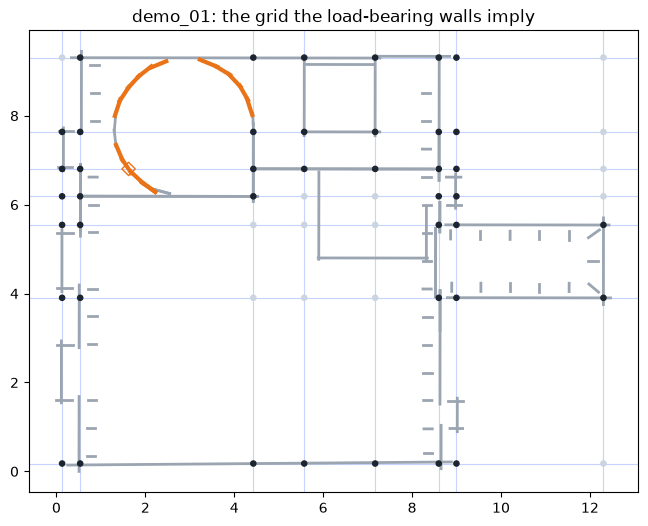

In [3]:
# A held-out dwelling, parsed load-bearing-aware. The fifth number on each
# wall is its measured thickness; only walls >= 160 mm vote.
plan = json.loads((Path("..") / "data" / "demo_plans" / "demo_01.json").read_text())
dcons = {"n_stories": plan["n_stories"], "min_span": 0.5, "max_span": 8.0,
         "merge_tol": "auto", "min_wall_frac": 0.05,
         "fixed_columns": plan.get("annotated_columns", []),
         "column_free_zones": []}
dgrid = P.parse_plan(plan["walls"], dcons)
thick = np.asarray(plan["walls"])[:, 4]
print(f"demo_01: {len(plan['walls'])} walls, "
      f"{int((thick >= 0.16).sum())} load-bearing at 160 mm; "
      f"grid {len(dgrid['x_lines'])} x {len(dgrid['y_lines'])}, "
      f"{int(dgrid['in_wall'].sum())} of {len(dgrid['nodes'])} nodes inside "
      f"a load-bearing wall, {len(dgrid['fixed_columns'])} drawn column(s)")
draw(dgrid, "demo_01: the grid the load-bearing walls imply",
     Path("..") / "figures" / "04_parsed_dwelling.png")

skew plan: 2 inclined walls, 1 crossing candidates (orange diamonds)


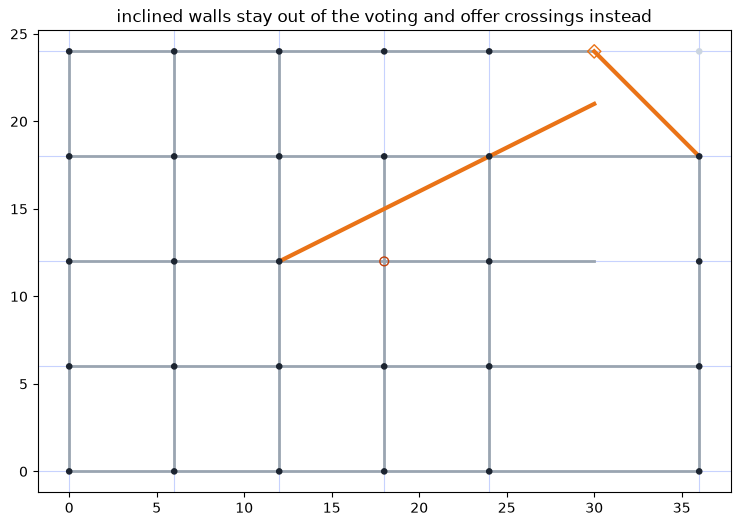

In [4]:
# Inclined walls: the office with a chamfered corner and a diagonal spine.
skew_walls = json.loads((Path("..") / "data" / "skew_plan.json").read_text())["walls"]
sgrid = P.parse_plan(skew_walls, cons)
print(f"skew plan: {len(sgrid['skew_walls'])} inclined walls, "
      f"{len(sgrid['skew_nodes'])} crossing candidates (orange diamonds)")
draw(sgrid, "inclined walls stay out of the voting and offer crossings instead",
     Path("..") / "figures" / "04_inclined_walls.png")

In [5]:
# The DXF reader gives the same grid as the JSON plan.
dxf_walls = P.read_dxf_walls(Path("..") / "data" / "test_plan.dxf")
dxf_grid = P.parse_plan(dxf_walls, cons)
assert np.allclose(dxf_grid["x_lines"], grid["x_lines"])
assert np.allclose(dxf_grid["y_lines"], grid["y_lines"])
print("DXF and JSON agree:", np.round(dxf_grid["x_lines"], 2))

# Hand the parsed sample grid to stage 05.
out = {k: (np.asarray(v).tolist() if isinstance(v, np.ndarray) else v)
       for k, v in P._grid_payload(grid).items()}
out["constraints"] = cons
(Path("..") / "data" / "parsed_grid.json").write_text(json.dumps(out))
print("wrote data/parsed_grid.json")

DXF and JSON agree: [ 0.  6. 12. 18. 24. 30. 36.]
wrote data/parsed_grid.json


## Why the alignment matters

The corpus ground truth was derived by one specific reading of the walls:
load-bearing only, midpoint votes, 1.5% tolerance, containment with each
wall's own thickness. If stage 04 read the walls any other way, the derived
arrangement could not appear among stage 05's candidates, and every accuracy
number in stage 12 would measure the disagreement between two parsers
rather than the quality of any variant (loophole L4). Aligning the parser
closed that: the ground truth is organically reachable on all seven
held-out plans. One consequence is stated openly: on those evaluation runs
the inclined-wall crossings are disabled, because the ground-truth
derivation cannot express a column off the orthogonal lattice; the skew
path remains live in the app and in this notebook's third figure.